# TCCT S81-CF — Paired Structural Counterfactual Audit

这是反事实协议审计，不是 blind counterfactual generalization test。第一格冻结 S80 架构；第二格在任何 pair 运行前锁定干预协议；第三格只评估 8 个孪生 pair（16 个世界）。

每对世界拥有相同 seed、节点、边数和逐节点度数。显式边干预把事实 Continue 世界变成 Stop 世界；逆干预必须精确恢复事实世界。S80 层级菱形作为中性干预，规范化后必须精确恢复各自世界。模型输入中不包含事实或反事实标签。


Dataset[{<|Stage -> S81-CF, Name -> PairedStructuralCounterfactualAudit, 
 
>     ArchitectureFrozenBeforeCounterfactualProtocol -> True, 
 
>     FrozenModelHash -> 
 
>      d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4, 
 
>     MinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     CanonicalizerImplementationHash -> 
 
>      5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d, 
 
>     FrozenArchitectureHash -> 
 
>      47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7, 
 
>     NeutralControlTopologyHash -> 
 
>      01af33358afe3fcfe876288b6de7c99a89af22599320fec75911661e240bc121, 
 
>     PriorS80BlindResultHash -> 
 
>      c5a15629ed0631b8217b474b5be6f514bb1b9a8564c96ac4d964b63f376c992f, 
 
>     HistoricalRegressionRerun -> False, S80BlindRerun -> False, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, PolicyEditApplied -> False, RetuningApplied -> False, 
 
>     FreezePreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, 
 
>      ArchitectureFrozenBeforeCounterfactualProtocol, FrozenModelHash, 
 
>      MinimalKernelHash, CanonicalizerImplementationHash, FrozenArchitectureHash, 
 
>      NeutralControlTopologyHash, PriorS80BlindResultHash, HistoricalRegressionRerun, 
 
>      S80BlindRerun, TrainingRun, CandidateSearchRun, PolicyEditApplied, 
 
>      RetuningApplied, FreezePreflightPassed}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
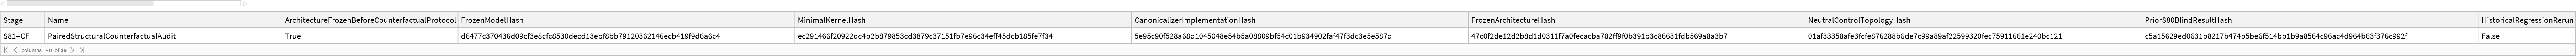

In [5]:



ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];expectedMinimalKernelHash81=
"ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34";
expectedCanonicalizerHash81=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedFrozenArchitectureHash81=
"47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7";
expectedS80TopologyHash81=
"01af33358afe3fcfe876288b6de7c99a89af22599320fec75911661e240bc121";
expectedS80BlindResultHash81=
"c5a15629ed0631b8217b474b5be6f514bb1b9a8564c96ac4d964b63f376c992f";

frozenArchitectureHash81=Hash[
{
Normal[frozen75D],
minimalKernelHash79A,
canonicalizerImplementationHash79B
},
"SHA256",
"HexString"
];

freezePreflightPassed81=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelHash79A,
expectedMinimalKernelHash81
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash81
],
SameQ[
frozenArchitectureHash81,
expectedFrozenArchitectureHash81
],
SameQ[
topologyImplementationHash80,
expectedS80TopologyHash81
]
];

freezeCertificate81=<|
"Stage"->"S81-CF",
"Name"->"PairedStructuralCounterfactualAudit",
"ArchitectureFrozenBeforeCounterfactualProtocol"->True,
"FrozenModelHash"->modelHash79A,
"MinimalKernelHash"->minimalKernelHash79A,
"CanonicalizerImplementationHash"->
canonicalizerImplementationHash79B,
"FrozenArchitectureHash"->frozenArchitectureHash81,
"NeutralControlTopologyHash"->
topologyImplementationHash80,
"PriorS80BlindResultHash"->
expectedS80BlindResultHash81,
"HistoricalRegressionRerun"->False,
"S80BlindRerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"FreezePreflightPassed"->freezePreflightPassed81
|>;

If[
!TrueQ[freezePreflightPassed81],
Print[Dataset[{freezeCertificate81}]];
Print["S81-CF aborted: frozen S80 architecture or control topology hash mismatch."];
Abort[]
];

Dataset[{freezeCertificate81}]


Dataset[{<|Stage -> S81-CF, ProtocolHash -> 
 
>      b52a02dba0886b9252ced6d418a084a3f53cc33d9ef514706722013f2ff8bd71, 
 
>     Depths -> {31, 63}, ExpectedPairs -> 8, ExpectedWorldsEvaluated -> 16, 
 
>     Intervention -> DegreePreservingGlobalSemanticEdgePermutation, 
 
>     ExpectedEdgeEditDistancePerPair -> 24, NoPairEvaluatedBeforeProtocolHash -> True, 
 
>     S81IsBlindCounterfactualTest -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, ProtocolHash, Depths, ExpectedPairs, 
 
>      ExpectedWorldsEvaluated, Intervention, ExpectedEdgeEditDistancePerPair, 
 
>      NoPairEvaluatedBeforeProtocolHash, S81IsBlindCounterfactualTest}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
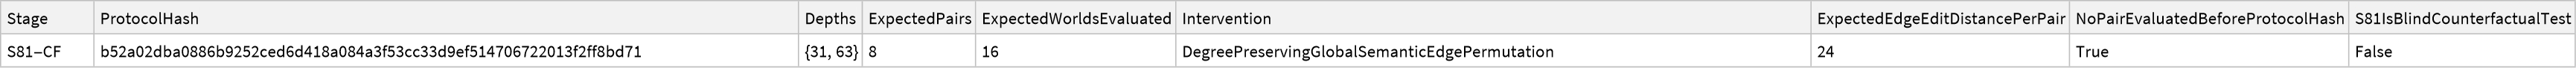

In [55]:
ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];

counterfactualDepths81={31,63};
counterfactualAnswers81=Range[4];

protocol81=<|
"Stage"->"S81-CF",
"Name"->"PairedStructuralCounterfactualAudit",
"Depths"->counterfactualDepths81,
"Answers"->counterfactualAnswers81,
"ExpectedPairs"->8,
"ExpectedWorldsEvaluated"->16,
"FactualAction"->"Continue",
"CounterfactualAction"->"Stop",
"Intervention"->
"DegreePreservingGlobalSemanticEdgePermutation",
"ExpectedRemovedEdgesPerPair"->12,
"ExpectedAddedEdgesPerPair"->12,
"ExpectedEdgeEditDistancePerPair"->24,
"SameSeedWithinPair"->True,
"SameVerticesWithinPair"->True,
"SamePerVertexDegreeProfileWithinPair"->True,
"InverseInterventionMustRecoverFactual"->True,
"NeutralControl"->
"S80HierarchicalDiamondThenFrozenCanonicalization",
"NeutralControlMustRecoverEachWorld"->True,
"ArchitectureFrozenBeforeProtocol"->True,
"NoPairEvaluatedBeforeProtocolHash"->True,
"HistoricalRegressionRerun"->False,
"S80BlindRerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"S81IsBlindCounterfactualTest"->False
|>;

protocolHash81=Hash[
Normal[protocol81],
"SHA256",
"HexString"
];

modelHashBeforeAudit81=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];
coreHashBeforeAudit81=minimalKernelHash79A;
canonicalizerHashBeforeAudit81=
canonicalizerImplementationHash79B;
neutralTopologyHashBeforeAudit81=
topologyImplementationHash80;
protocolHashBeforeAudit81=protocolHash81;

Dataset[{<|
"Stage"->"S81-CF",
"ProtocolHash"->protocolHash81,
"Depths"->counterfactualDepths81,
"ExpectedPairs"->8,
"ExpectedWorldsEvaluated"->16,
"Intervention"->
"DegreePreservingGlobalSemanticEdgePermutation",
"ExpectedEdgeEditDistancePerPair"->24,
"NoPairEvaluatedBeforeProtocolHash"->True,
"S81IsBlindCounterfactualTest"->False
|>}]


In [74]:
ClearAll[
PredictCodes81,
EvaluateArchitecture81,
PrepareCounterfactualPair81
];

PredictCodes81[codes_List]:=If[
AnyTrue[codes,MemberQ[frozen75D["Policy"],#]&],
"Continue",
"Stop"
];

EvaluateArchitecture81[
c_List,
depth_Integer,
answer_Integer,
worldName_String
]:=Module[
{
canonicalization,canonicalCase,traceSeconds,trace,
pairs,encoded,codes,prediction
},
canonicalization=CanonicalizePrivateDiamonds79B[c];
canonicalCase=canonicalization["Case"];
{traceSeconds,trace}=AbsoluteTiming[
RejectTrace78[canonicalCase]
];
pairs=DecisionStatePairsFromRejects78[
canonicalCase,
trace["Rejects"]
];
encoded=First@EncodeRows75[
{<|
"Grammar"->"S81CounterfactualWorld",
"Depth"->depth,
"Answer"->answer,
"Target"->"Unlabeled",
"StatePairs"->pairs
|>},
frozen75D["Params"],
frozen75D["K"]
];
codes=encoded["Codes"];
prediction=PredictCodes81[codes];
<|
"World"->worldName,
"CanonicalizationContractions"->
canonicalization["Contractions"],
"CanonicalCase"->canonicalCase,
"TraceSeconds"->traceSeconds,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"StatePairCount"->Length[pairs],
"Codes"->codes,
"Prediction"->prediction
|>
];

PrepareCounterfactualPair81[
depth_Integer,
answer_Integer
]:=Module[
{
factualCase,counterfactualTemplate,patch,
counterfactualCase,inversePatch,recoveredFactual,
neutralFactual,neutralCounterfactual,
factualEvaluation,counterfactualEvaluation,
factualPrediction,counterfactualPrediction,
pairCorrect,flipCorrect
},
factualCase=Case59[depth,answer,"Continue"];
counterfactualTemplate=Case59[
depth,answer,"Stop"
];
patch=EdgePatch81[
factualCase,
counterfactualTemplate
];
counterfactualCase=ApplyEdgePatch81[
factualCase,
patch
];
inversePatch=InverseEdgePatch81[patch];
recoveredFactual=ApplyEdgePatch81[
counterfactualCase,
inversePatch
];
neutralFactual=CanonicalCase79B[
HierarchicalDiamondIn80[factualCase]
];
neutralCounterfactual=CanonicalCase79B[
HierarchicalDiamondIn80[counterfactualCase]
];
factualEvaluation=EvaluateArchitecture81[
factualCase,
depth,
answer,
"FactualContinue"
];
counterfactualEvaluation=EvaluateArchitecture81[
counterfactualCase,
depth,
answer,
"CounterfactualStop"
];
factualPrediction=factualEvaluation["Prediction"];
counterfactualPrediction=
counterfactualEvaluation["Prediction"];
pairCorrect=And[
SameQ[factualPrediction,"Continue"],
SameQ[counterfactualPrediction,"Stop"]
];
flipCorrect=And[
SameQ[factualPrediction,"Continue"],
SameQ[
counterfactualPrediction,
OppositeAction81[factualPrediction]
]
];
<|
"Depth"->depth,
"Answer"->answer,
"FactualTarget"->"Continue",
"CounterfactualTarget"->"Stop",
"RemovedEdges"->Length[patch["Remove"]],
"AddedEdges"->Length[patch["Add"]],
"EdgeEditDistance"->Total[
Length/@Lookup[patch,{"Remove","Add"}]
],
"CounterfactualCaseExactlyTemplate"->SameQ[
counterfactualCase,
counterfactualTemplate
],
"SameVertices"->SameQ[
VertexSet81[factualCase],
VertexSet81[counterfactualCase]
],
"SameEdgeCount"->SameQ[
Length[EdgeSet81[factualCase]],
Length[EdgeSet81[counterfactualCase]]
],
"SamePerVertexDegreeProfile"->SameQ[
VertexDegreeProfile81[factualCase],
VertexDegreeProfile81[counterfactualCase]
],
"InverseInterventionRecoversFactual"->SameQ[
recoveredFactual,
factualCase
],
"NeutralFactualRecoversExact"->SameQ[
neutralFactual,
factualCase
],
"NeutralCounterfactualRecoversExact"->SameQ[
neutralCounterfactual,
counterfactualCase
],
"FactualCodes"->factualEvaluation["Codes"],
"CounterfactualCodes"->
counterfactualEvaluation["Codes"],
"FactualPrediction"->factualPrediction,
"CounterfactualPrediction"->
counterfactualPrediction,
"FactualCorrect"->SameQ[
factualPrediction,
"Continue"
],
"CounterfactualCorrect"->SameQ[
counterfactualPrediction,
"Stop"
],
"PairCorrect"->pairCorrect,
"FlipDirectionCorrect"->flipCorrect,
"ReverseDirectionCorrect"->And[
SameQ[counterfactualPrediction,"Stop"],
SameQ[
factualPrediction,
OppositeAction81[counterfactualPrediction]
]
],
"FactualTerminatedNaturally"->
factualEvaluation["TerminatedNaturally"],
"CounterfactualTerminatedNaturally"->
counterfactualEvaluation["TerminatedNaturally"],
"FactualHitSafetyCap"->
factualEvaluation["HitSafetyCap"],
"CounterfactualHitSafetyCap"->
counterfactualEvaluation["HitSafetyCap"],
"FactualStatePairCount"->
factualEvaluation["StatePairCount"],
"CounterfactualStatePairCount"->
counterfactualEvaluation["StatePairCount"],
"TotalTraceSeconds"->Total[{
factualEvaluation["TraceSeconds"],
counterfactualEvaluation["TraceSeconds"]
}]
|>
];

counterfactualPairs81=Flatten[
Table[
PrepareCounterfactualPair81[depth,answer],
{depth,counterfactualDepths81},
{answer,counterfactualAnswers81}
],
1
];

counterfactualSummary81=<|
"Stage"->"S81-CF",
"Pairs"->Length[counterfactualPairs81],
"WorldsEvaluated"->2 Length[counterfactualPairs81],
"FactualCorrect"->Count[
counterfactualPairs81,
row_/;TrueQ[row["FactualCorrect"]]
],
"CounterfactualCorrect"->Count[
counterfactualPairs81,
row_/;TrueQ[row["CounterfactualCorrect"]]
],
"PairCorrect"->Count[
counterfactualPairs81,
row_/;TrueQ[row["PairCorrect"]]
],
"FlipDirectionCorrect"->Count[
counterfactualPairs81,
row_/;TrueQ[row["FlipDirectionCorrect"]]
],
"ReverseDirectionCorrect"->Count[
counterfactualPairs81,
row_/;TrueQ[row["ReverseDirectionCorrect"]]
],
"CounterfactualCaseExactlyTemplate"->Count[
counterfactualPairs81,
row_/;TrueQ[row["CounterfactualCaseExactlyTemplate"]]
],
"SameVertices"->Count[
counterfactualPairs81,
row_/;TrueQ[row["SameVertices"]]
],
"SameEdgeCount"->Count[
counterfactualPairs81,
row_/;TrueQ[row["SameEdgeCount"]]
],
"SamePerVertexDegreeProfile"->Count[
counterfactualPairs81,
row_/;TrueQ[row["SamePerVertexDegreeProfile"]]
],
"InverseInterventionRecovery"->Count[
counterfactualPairs81,
row_/;TrueQ[row["InverseInterventionRecoversFactual"]]
],
"NeutralFactualInvariance"->Count[
counterfactualPairs81,
row_/;TrueQ[row["NeutralFactualRecoversExact"]]
],
"NeutralCounterfactualInvariance"->Count[
counterfactualPairs81,
row_/;TrueQ[row["NeutralCounterfactualRecoversExact"]]
],
"RemovedEdgeCounts"->Counts@Lookup[
counterfactualPairs81,
"RemovedEdges"
],
"AddedEdgeCounts"->Counts@Lookup[
counterfactualPairs81,
"AddedEdges"
],
"EdgeEditDistances"->Counts@Lookup[
counterfactualPairs81,
"EdgeEditDistance"
],
"FactualCodeSet"->Union@@Lookup[
counterfactualPairs81,
"FactualCodes"
],
"CounterfactualCodeSet"->Union@@Lookup[
counterfactualPairs81,
"CounterfactualCodes"
],
"WorldsTerminatedNaturally"->Plus[
Count[
Lookup[counterfactualPairs81,"FactualTerminatedNaturally"],
True
],
Count[
Lookup[counterfactualPairs81,"CounterfactualTerminatedNaturally"],
True
]
],
"WorldsHitSafetyCap"->Plus[
Count[
Lookup[counterfactualPairs81,"FactualHitSafetyCap"],
True
],
Count[
Lookup[counterfactualPairs81,"CounterfactualHitSafetyCap"],
True
]
],
"TotalTraceSeconds"->Total@Lookup[
counterfactualPairs81,
"TotalTraceSeconds"
]
|>;

Dataset[{counterfactualSummary81}]


Dataset[{<|Stage -> S81-CF, Pairs -> 8, WorldsEvaluated -> 16, FactualCorrect -> 8, 
 
>     CounterfactualCorrect -> 8, PairCorrect -> 8, FlipDirectionCorrect -> 8, 
 
>     ReverseDirectionCorrect -> 8, CounterfactualCaseExactlyTemplate -> 8, 
 
>     SameVertices -> 8, SameEdgeCount -> 8, SamePerVertexDegreeProfile -> 8, 
 
>     InverseInterventionRecovery -> 8, NeutralFactualInvariance -> 8, 
 
>     NeutralCounterfactualInvariance -> 8, RemovedEdgeCounts -> <|12 -> 8|>, 
 
>     AddedEdgeCounts -> <|12 -> 8|>, EdgeEditDistances -> <|24 -> 8|>, 
 
>     FactualCodeSet -> {{3, 3}, {4, 3}}, CounterfactualCodeSet -> {{4, 4}, {5, 4}}, 
 
>     WorldsTerminatedNaturally -> 16, WorldsHitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 5.32341|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 23], 
 
>    1], <||>]

Dataset[{<|Stage -> S81-CF, Name -> PairedStructuralCounterfactualAudit, Pairs -> 8, 
 
>     WorldsEvaluated -> 16, FactualCorrect -> 8, CounterfactualCorrect -> 8, 
 
>     PairCorrect -> 8, FlipDirectionCorrect -> 8, ReverseDirectionCorrect -> 8, 
 
>     SameVertices -> 8, SameEdgeCount -> 8, SamePerVertexDegreeProfile -> 8, 
 
>     InverseInterventionRecovery -> 8, NeutralFactualInvariance -> 8, 
 
>     NeutralCounterfactualInvariance -> 8, RemovedEdgeCounts -> <|12 -> 8|>, 
 
>     AddedEdgeCounts -> <|12 -> 8|>, EdgeEditDistances -> <|24 -> 8|>, 
 
>     FactualCodeSet -> {{3, 3}, {4, 3}}, CounterfactualCodeSet -> {{4, 4}, {5, 4}}, 
 
>     ModelUnchanged -> True, CoreUnchanged -> True, CanonicalizerUnchanged -> True, 
 
>     NeutralTopologyUnchanged -> True, ProtocolUnchanged -> True, 
 
>     AuditValidityPassed -> True, KnownInterventionAuditPassed -> True, 
 
>     CounterfactualMethod -> ExternalGraphInterventionAndFrozenForwardSimulation, 
 
>     S81IsBlindCounterfactualTest -> False, 
 
>     MayClaimCounterfactualProtocolOperational -> True, 
 
>     MayClaimKnownInterventionPairedCounterfactualReasoning -> True, 
 
>     MayClaimBlindCounterfactualGeneralization -> False, 
 
>     MayClaimCausalDiscovery -> False, TotalTraceSeconds -> 5.32341, 
 
>     ResultHash -> e9f2653325a5f4a024c1b3a3678c94eba24532d1ab9461569c2a9b7a2f9190d7, 
 
>     Outcome -> PAIRED_STRUCTURAL_COUNTERFACTUAL_AUDIT_PASS, 
 
>     SuggestedNextStage -> S82_BLIND_LOCAL_MEDIATOR_INTERVENTION_TEST|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 37], 
 
>    1], <||>]
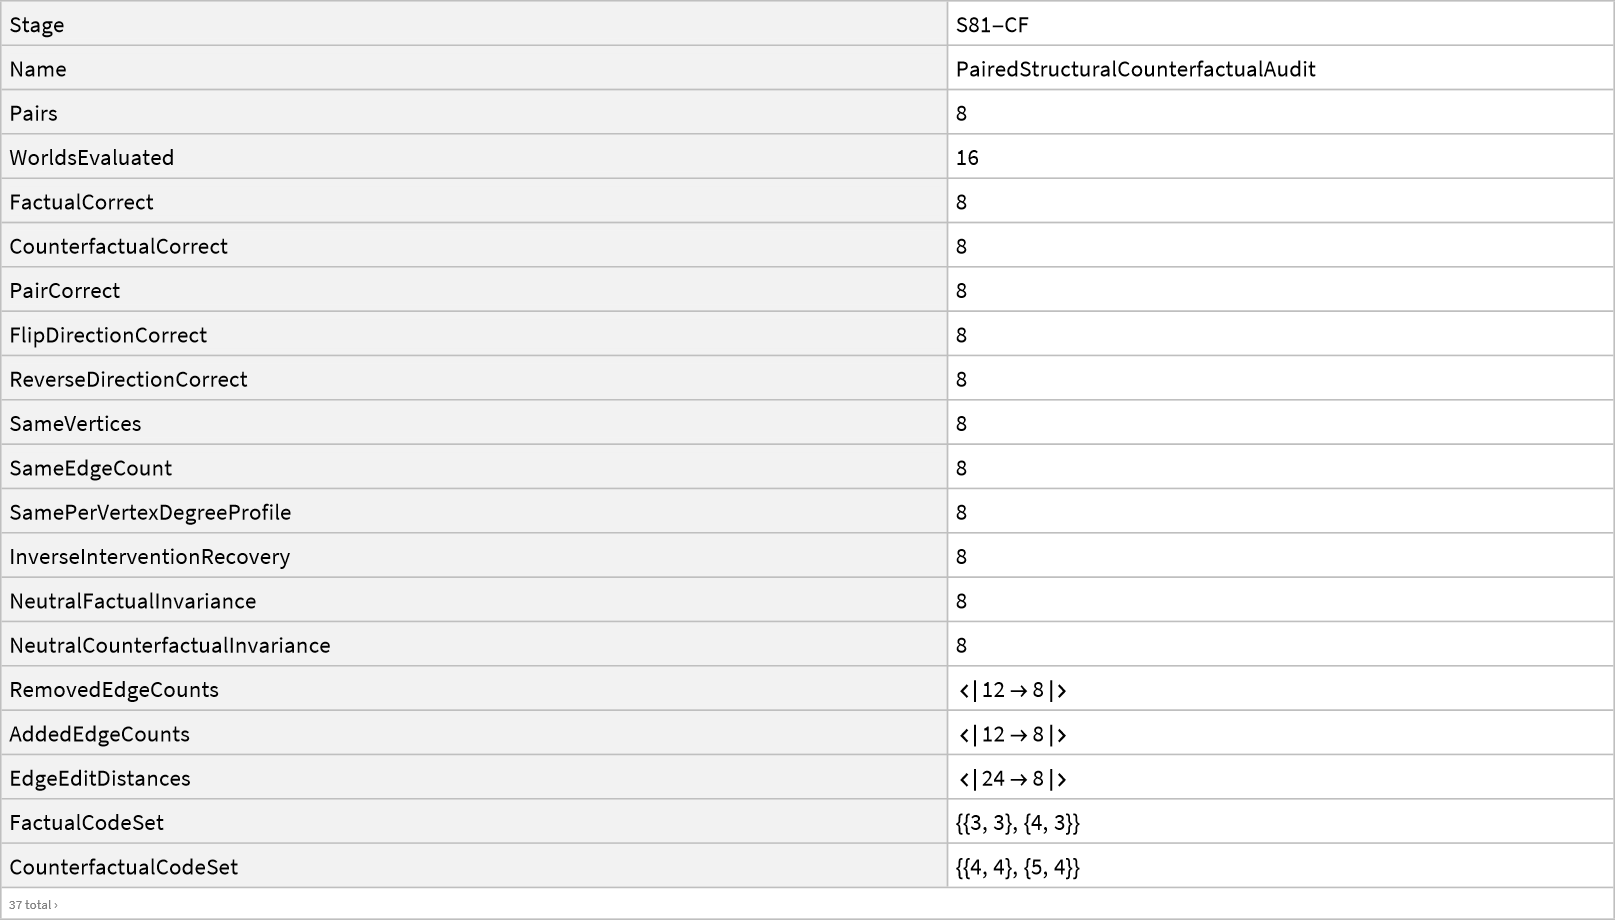

In [81]:
modelHashAfterAudit81=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];
coreHashAfterAudit81=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];
canonicalizerHashAfterAudit81=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];
neutralTopologyHashAfterAudit81=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];
protocolHashAfterAudit81=Hash[
Normal[protocol81],
"SHA256",
"HexString"
];

modelUnchanged81=And[
SameQ[modelHashBeforeAudit81,modelHashAfterAudit81],
SameQ[modelHashAfterAudit81,expectedFrozenModelHash79A]
];
coreUnchanged81=And[
SameQ[coreHashBeforeAudit81,coreHashAfterAudit81],
SameQ[coreHashAfterAudit81,expectedMinimalKernelHash81]
];
canonicalizerUnchanged81=And[
SameQ[
canonicalizerHashBeforeAudit81,
canonicalizerHashAfterAudit81
],
SameQ[
canonicalizerHashAfterAudit81,
expectedCanonicalizerHash81
]
];
neutralTopologyUnchanged81=And[
SameQ[
neutralTopologyHashBeforeAudit81,
neutralTopologyHashAfterAudit81
],
SameQ[
neutralTopologyHashAfterAudit81,
expectedS80TopologyHash81
]
];
protocolUnchanged81=SameQ[
protocolHashBeforeAudit81,
protocolHashAfterAudit81
];

auditValidityPassed81=And[
TrueQ[freezePreflightPassed81],
TrueQ[modelUnchanged81],
TrueQ[coreUnchanged81],
TrueQ[canonicalizerUnchanged81],
TrueQ[neutralTopologyUnchanged81],
TrueQ[protocolUnchanged81],
SameQ[Length[counterfactualPairs81],8],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["CounterfactualCaseExactlyTemplate"]]
],
8
],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["SameVertices"]]
],
8
],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["SameEdgeCount"]]
],
8
],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["SamePerVertexDegreeProfile"]]
],
8
],
SameQ[Counts@Lookup[counterfactualPairs81,"RemovedEdges"],<|12->8|>],
SameQ[Counts@Lookup[counterfactualPairs81,"AddedEdges"],<|12->8|>],
SameQ[Counts@Lookup[counterfactualPairs81,"EdgeEditDistance"],<|24->8|>],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["InverseInterventionRecoversFactual"]]
],
8
],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["NeutralFactualRecoversExact"]]
],
8
],
SameQ[
Count[
counterfactualPairs81,
row_/;TrueQ[row["NeutralCounterfactualRecoversExact"]]
],
8
],
SameQ[
counterfactualSummary81["WorldsTerminatedNaturally"],
16
],
SameQ[counterfactualSummary81["WorldsHitSafetyCap"],0]
];

knownInterventionAuditPassed81=And[
TrueQ[auditValidityPassed81],
SameQ[counterfactualSummary81["FactualCorrect"],8],
SameQ[counterfactualSummary81["CounterfactualCorrect"],8],
SameQ[counterfactualSummary81["PairCorrect"],8],
SameQ[counterfactualSummary81["FlipDirectionCorrect"],8],
SameQ[counterfactualSummary81["ReverseDirectionCorrect"],8]
];

resultPayload81=<|
"Stage"->"S81-CF",
"Name"->"PairedStructuralCounterfactualAudit",
"FrozenArchitectureHash"->frozenArchitectureHash81,
"PriorS80BlindResultHash"->expectedS80BlindResultHash81,
"ProtocolHash"->protocolHashAfterAudit81,
"Pairs"->Length[counterfactualPairs81],
"WorldsEvaluated"->2 Length[counterfactualPairs81],
"FactualCorrect"->counterfactualSummary81["FactualCorrect"],
"CounterfactualCorrect"->
counterfactualSummary81["CounterfactualCorrect"],
"PairCorrect"->counterfactualSummary81["PairCorrect"],
"FlipDirectionCorrect"->
counterfactualSummary81["FlipDirectionCorrect"],
"ReverseDirectionCorrect"->
counterfactualSummary81["ReverseDirectionCorrect"],
"SameVertices"->counterfactualSummary81["SameVertices"],
"SameEdgeCount"->counterfactualSummary81["SameEdgeCount"],
"SamePerVertexDegreeProfile"->
counterfactualSummary81["SamePerVertexDegreeProfile"],
"InverseInterventionRecovery"->
counterfactualSummary81["InverseInterventionRecovery"],
"NeutralFactualInvariance"->
counterfactualSummary81["NeutralFactualInvariance"],
"NeutralCounterfactualInvariance"->
counterfactualSummary81["NeutralCounterfactualInvariance"],
"RemovedEdgeCounts"->
counterfactualSummary81["RemovedEdgeCounts"],
"AddedEdgeCounts"->counterfactualSummary81["AddedEdgeCounts"],
"EdgeEditDistances"->
counterfactualSummary81["EdgeEditDistances"],
"FactualCodeSet"->counterfactualSummary81["FactualCodeSet"],
"CounterfactualCodeSet"->
counterfactualSummary81["CounterfactualCodeSet"],
"ModelUnchanged"->modelUnchanged81,
"CoreUnchanged"->coreUnchanged81,
"CanonicalizerUnchanged"->canonicalizerUnchanged81,
"NeutralTopologyUnchanged"->neutralTopologyUnchanged81,
"ProtocolUnchanged"->protocolUnchanged81,
"AuditValidityPassed"->auditValidityPassed81,
"KnownInterventionAuditPassed"->
knownInterventionAuditPassed81
|>;

resultHash81=Hash[
Normal[resultPayload81],
"SHA256",
"HexString"
];

cert81=Join[
resultPayload81,
<|
"CounterfactualMethod"->
"ExternalGraphInterventionAndFrozenForwardSimulation",
"HistoricalRegressionRerun"->False,
"S80BlindRerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"OverallArchitectureChangedDuringS81"->False,
"S81IsBlindCounterfactualTest"->False,
"MayClaimCounterfactualProtocolOperational"->
knownInterventionAuditPassed81,
"MayClaimKnownInterventionPairedCounterfactualReasoning"->
knownInterventionAuditPassed81,
"MayClaimBlindCounterfactualGeneralization"->False,
"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->
counterfactualSummary81["TotalTraceSeconds"],
"ResultHash"->resultHash81,
"Outcome"->Which[
!TrueQ[auditValidityPassed81],
"INVALID_COUNTERFACTUAL_AUDIT",
TrueQ[knownInterventionAuditPassed81],
"PAIRED_STRUCTURAL_COUNTERFACTUAL_AUDIT_PASS",
True,
"VALID_COUNTERFACTUAL_AUDIT_FAILURE"
],
"SuggestedNextStage"->If[
TrueQ[knownInterventionAuditPassed81],
"S82_BLIND_LOCAL_MEDIATOR_INTERVENTION_TEST",
"DIAGNOSE_S81_WITHOUT_RETUNING_FROZEN_ARCHITECTURE"
]
|>
];

Dataset[{KeyTake[
cert81,
{
"Stage",
"Name",
"Pairs",
"WorldsEvaluated",
"FactualCorrect",
"CounterfactualCorrect",
"PairCorrect",
"FlipDirectionCorrect",
"ReverseDirectionCorrect",
"SameVertices",
"SameEdgeCount",
"SamePerVertexDegreeProfile",
"InverseInterventionRecovery",
"NeutralFactualInvariance",
"NeutralCounterfactualInvariance",
"RemovedEdgeCounts",
"AddedEdgeCounts",
"EdgeEditDistances",
"FactualCodeSet",
"CounterfactualCodeSet",
"ModelUnchanged",
"CoreUnchanged",
"CanonicalizerUnchanged",
"NeutralTopologyUnchanged",
"ProtocolUnchanged",
"AuditValidityPassed",
"KnownInterventionAuditPassed",
"CounterfactualMethod",
"S81IsBlindCounterfactualTest",
"MayClaimCounterfactualProtocolOperational",
"MayClaimKnownInterventionPairedCounterfactualReasoning",
"MayClaimBlindCounterfactualGeneralization",
"MayClaimCausalDiscovery",
"TotalTraceSeconds",
"ResultHash",
"Outcome",
"SuggestedNextStage"
}
]}]
